 # 02 — Initial Distance-Based Testing on FPCA Scores



 This notebook performs an initial comparison of distance-based classifiers on

 sampled Gaia XP spectra after FPCA projection.



 Main pipeline:



 1. Load sampled spectra.

 2. Apply row-wise L2 normalisation.

 3. Split the data into train and test sets.

 4. Project spectra into FPCA score space.

 5. Evaluate distance-based classifiers.

 6. Save result tables and thesis-ready figures.



 The notebook is exploratory. It is used to test whether simple distance-based

 methods can separate binary and non-binary hot subdwarf candidates in a

 low-dimensional functional score space.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    pairwise_distances,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")



 ## 1. General configuration



 This section defines the main experiment settings.



 - `RANDOM_STATE` keeps the train/test split reproducible.

 - `TEST_SIZE` defines the share of data used as the test set.

 - `K_DEFAULT` defines the number of neighbours for kNN models.

 - `J_VALUES` defines the tested numbers of FPCA components.

 - `DISTANCES` lists the distance metrics used by the classifiers.

 - `TOP_N_PLOT` controls how many top models are shown in the comparison plot.

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TEST_SIZE = 0.20
K_DEFAULT = 5

J_VALUES = [1, 2, 3, 5, 10, 15, 20, 30]


DISTANCES = [
    "euclidean",
    "manhattan",
    "cosine",
    "correlation",
    "seuclidean",
    "mahalanobis",
]

TOP_N_PLOT = 12



 ## 2. Paths and input files



 The notebook expects the sampled spectra file to be stored in the `og_data`

 directory. Results are saved to `results/02_initial_model_testing`.

In [3]:
DATA_DIR = Path.cwd() / "og_data"
OUT_DIR = Path.cwd() / "results" / "02_initial_model_testing"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLED_CANDIDATES = [
    DATA_DIR / "xp_sampled_spectra.csv",
]



 ## 3. Plot style



 This section defines a consistent thesis-ready style for all figures.

 The same visual style is reused throughout the notebook.

In [4]:
COLOR_PRIMARY = "#6193CD"
COLOR_SECONDARY = "#8C8C8C"
COLOR_DARK = "#4A4A4A"
COLOR_LIGHT = "#D9D9D9"
COLOR_TEXT = "#222222"

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "axes.edgecolor": "#444444",
        "axes.linewidth": 0.8,
        "axes.labelcolor": COLOR_TEXT,
        "xtick.color": COLOR_TEXT,
        "ytick.color": COLOR_TEXT,
        "text.color": COLOR_TEXT,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)



 ## 4. Helper functions



 These functions keep the main experiment code shorter and easier to read.

 Each function has a short docstring explaining what it does.

In [5]:
def apply_clean_axes(ax, add_grid: bool = False) -> None:
    """Apply clean thesis-style formatting to a matplotlib axis.

    The function removes the top and right borders. Optionally, it also adds
    a light dashed grid on the x-axis, which is useful for horizontal bar plots.

    Parameters
    ----------
    ax:
        Matplotlib axis object.
    add_grid:
        Whether to add a light dashed grid.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if add_grid:
        ax.grid(
            True,
            axis="x",
            linestyle="--",
            linewidth=0.6,
            alpha=0.5,
            color=COLOR_LIGHT,
        )
    else:
        ax.grid(False)


def show_and_save(fig, path: Path) -> None:
    """Show a figure and immediately save it as an SVG file.

    This avoids a separate figure-saving block at the end of the notebook and
    keeps each figure export next to the corresponding plotting code.

    Parameters
    ----------
    fig:
        Matplotlib figure object.
    path:
        Output path for the SVG file.
    """
    plt.tight_layout()
    plt.show()
    fig.savefig(path, format="svg", bbox_inches="tight", facecolor="white")
    plt.close(fig)


def find_first_existing(paths: Sequence[Path]) -> Optional[Path]:
    """Return the first existing path from a list of candidate paths.

    Parameters
    ----------
    paths:
        Candidate file paths.

    Returns
    -------
    Optional[Path]
        First existing path, or `None` if no path exists.
    """
    for path in paths:
        if path.exists():
            return path

    return None


def l2_normalize_rows(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Apply row-wise L2 normalisation to a matrix.

    Each spectrum is divided by its L2 norm. This makes the analysis focus on
    spectral shape rather than overall flux scale.

    Parameters
    ----------
    X:
        Input matrix where rows are spectra and columns are wavelengths.
    eps:
        Small value used to avoid division by zero.

    Returns
    -------
    np.ndarray
        Row-wise L2-normalised matrix.
    """
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.maximum(norms, eps)

    return X / norms


def evaluate_binary(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: Optional[np.ndarray] = None,
) -> dict[str, float]:
    """Calculate binary classification metrics.

    Accuracy, precision, recall, sensitivity, specificity, and F1 are
    calculated from hard class predictions. PR-AUC is calculated from
    continuous class-1 scores when they are available.

    Parameters
    ----------
    y_true:
        True binary labels.
    y_pred:
        Predicted binary labels.
    y_score:
        Continuous class-1 scores. If not provided, PR-AUC is returned as NaN.

    Returns
    -------
    dict[str, float]
        Dictionary with binary classification metrics.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    if y_score is None:
        pr_auc = np.nan
    else:
        y_score = np.asarray(y_score, dtype=float)
        y_score = np.nan_to_num(
            y_score,
            nan=0.0,
            posinf=1.0,
            neginf=0.0,
        )
        pr_auc = average_precision_score(y_true, y_score)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": pr_auc,
    }


def fit_mahalanobis_matrix(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    eps: float = 1e-4,
) -> np.ndarray:
    """Estimate the inverse covariance matrix for Mahalanobis distance.

    A pooled within-class covariance matrix is estimated from the training
    data. A small ridge term is added to make the matrix numerically stable.

    Parameters
    ----------
    X_tr:
        Training feature matrix.
    y_tr:
        Training labels.
    eps:
        Ridge term added to the diagonal of the covariance matrix.

    Returns
    -------
    np.ndarray
        Pseudo-inverse of the regularised pooled covariance matrix.
    """
    n_features = X_tr.shape[1]
    pooled_covariance = np.zeros((n_features, n_features))

    classes = np.unique(y_tr)

    for cls in classes:
        X_cls = X_tr[y_tr == cls]
        centered_cls = X_cls - X_cls.mean(axis=0)
        pooled_covariance += centered_cls.T @ centered_cls

    denominator = max(len(X_tr) - len(classes), 1)
    pooled_covariance /= denominator
    pooled_covariance += eps * np.eye(n_features)

    return np.linalg.pinv(pooled_covariance)


def pairwise_distance_train_test(
    X_te: np.ndarray,
    X_tr: np.ndarray,
    metric_name: str,
    y_tr: Optional[np.ndarray] = None,
) -> np.ndarray:
    """Calculate distances between test and training observations.

    The function wraps several distance metrics into one interface. For
    standardized Euclidean and Mahalanobis distances, the necessary scaling or
    covariance information is estimated from the training data only.

    Parameters
    ----------
    X_te:
        Test feature matrix.
    X_tr:
        Training feature matrix.
    metric_name:
        Name of the distance metric.
    y_tr:
        Training labels, required for Mahalanobis distance.

    Returns
    -------
    np.ndarray
        Pairwise distance matrix with shape `(n_test, n_train)`.
    """
    if metric_name == "euclidean":
        return pairwise_distances(X_te, X_tr, metric="euclidean")

    if metric_name == "manhattan":
        return pairwise_distances(X_te, X_tr, metric="manhattan")

    if metric_name == "cosine":
        return pairwise_distances(X_te, X_tr, metric="cosine")

    if metric_name == "correlation":
        return pairwise_distances(X_te, X_tr, metric="correlation")

    if metric_name == "seuclidean":
        variances = np.var(X_tr, axis=0, ddof=1)
        variances = np.where(variances <= 1e-12, 1e-12, variances)

        return pairwise_distances(
            X_te,
            X_tr,
            metric="seuclidean",
            V=variances,
        )

    if metric_name == "mahalanobis":
        inverse_covariance = fit_mahalanobis_matrix(X_tr, y_tr)

        return pairwise_distances(
            X_te,
            X_tr,
            metric="mahalanobis",
            VI=inverse_covariance,
        )

    raise ValueError(f"Unknown metric: {metric_name}")


def pairwise_distance_to_reference(
    X_te: np.ndarray,
    X_ref: np.ndarray,
    X_tr_ref: np.ndarray,
    metric_name: str,
    y_tr: Optional[np.ndarray] = None,
) -> np.ndarray:
    """Calculate distances from observations to class reference points.

    This function is used for centroid and medoid classifiers, where each
    class is represented by one reference point.

    Parameters
    ----------
    X_te:
        Observations to classify.
    X_ref:
        Class reference points.
    X_tr_ref:
        Training data used to estimate scaling or covariance parameters.
    metric_name:
        Name of the distance metric.
    y_tr:
        Training labels, required for Mahalanobis distance.

    Returns
    -------
    np.ndarray
        Distance matrix with shape `(n_observations, n_references)`.
    """
    if metric_name == "euclidean":
        return pairwise_distances(X_te, X_ref, metric="euclidean")

    if metric_name == "manhattan":
        return pairwise_distances(X_te, X_ref, metric="manhattan")

    if metric_name == "cosine":
        return pairwise_distances(X_te, X_ref, metric="cosine")

    if metric_name == "correlation":
        return pairwise_distances(X_te, X_ref, metric="correlation")

    if metric_name == "seuclidean":
        variances = np.var(X_tr_ref, axis=0, ddof=1)
        variances = np.where(variances <= 1e-12, 1e-12, variances)

        return pairwise_distances(
            X_te,
            X_ref,
            metric="seuclidean",
            V=variances,
        )

    if metric_name == "mahalanobis":
        inverse_covariance = fit_mahalanobis_matrix(X_tr_ref, y_tr)

        return pairwise_distances(
            X_te,
            X_ref,
            metric="mahalanobis",
            VI=inverse_covariance,
        )

    raise ValueError(f"Unknown metric: {metric_name}")


def distance_score_from_two_refs(
    distances: np.ndarray,
    eps: float = 1e-12,
) -> np.ndarray:
    """Convert distances to two class references into a class-1 score.

    The first distance column is assumed to refer to class 0, and the second
    distance column is assumed to refer to class 1. The score is higher when
    the object is closer to the class-1 reference.

    Parameters
    ----------
    distances:
        Distance matrix with two columns: class 0 and class 1 references.
    eps:
        Small value used to avoid division by zero.

    Returns
    -------
    np.ndarray
        Continuous class-1 score.
    """
    distances = np.asarray(distances, dtype=float)
    distances = np.nan_to_num(
        distances,
        nan=np.inf,
        posinf=np.inf,
        neginf=0.0,
    )

    distance_to_class_0 = distances[:, 0]
    distance_to_class_1 = distances[:, 1]

    score = distance_to_class_0 / (
        distance_to_class_0 + distance_to_class_1 + eps
    )
    score = np.nan_to_num(score, nan=0.5, posinf=1.0, neginf=0.0)

    return score


def centroid_predict_score(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    metric_name: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Predict labels using class centroids.

    Each class is represented by its mean point in the feature space. Objects
    are assigned to the closer centroid.

    Parameters
    ----------
    X_tr:
        Training feature matrix.
    y_tr:
        Training labels.
    X_te:
        Test feature matrix.
    metric_name:
        Distance metric used for classification.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Predicted labels and continuous class-1 scores.
    """
    centroid_0 = X_tr[y_tr == 0].mean(axis=0, keepdims=True)
    centroid_1 = X_tr[y_tr == 1].mean(axis=0, keepdims=True)
    references = np.vstack([centroid_0, centroid_1])

    distances = pairwise_distance_to_reference(
        X_te,
        references,
        X_tr,
        metric_name,
        y_tr,
    )
    y_score = distance_score_from_two_refs(distances)
    y_pred = (y_score > 0.5).astype(int)

    return y_pred, y_score


def centroid_predict(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    metric_name: str,
) -> np.ndarray:
    """Return hard centroid-classifier predictions.

    This is a convenience wrapper around `centroid_predict_score` when only
    class labels are needed.

    Parameters
    ----------
    X_tr:
        Training feature matrix.
    y_tr:
        Training labels.
    X_te:
        Test feature matrix.
    metric_name:
        Distance metric used for classification.

    Returns
    -------
    np.ndarray
        Predicted binary labels.
    """
    y_pred, _ = centroid_predict_score(X_tr, y_tr, X_te, metric_name)

    return y_pred


def get_class_medoid(
    X_cls: np.ndarray,
    X_tr_ref: np.ndarray,
    y_tr: np.ndarray,
    metric_name: str,
) -> np.ndarray:
    """Find the medoid of one class.

    The medoid is the real observation with the smallest total distance to all
    other observations in the same class.

    Parameters
    ----------
    X_cls:
        Feature matrix of one class.
    X_tr_ref:
        Full training matrix used for metric scaling.
    y_tr:
        Training labels.
    metric_name:
        Distance metric used to compute within-class distances.

    Returns
    -------
    np.ndarray
        One-row matrix containing the class medoid.
    """
    if len(X_cls) == 1:
        return X_cls[0:1]

    distances = pairwise_distance_to_reference(
        X_cls,
        X_cls,
        X_tr_ref,
        metric_name,
        y_tr,
    )
    distances = np.nan_to_num(
        distances,
        nan=np.inf,
        posinf=np.inf,
        neginf=0.0,
    )

    medoid_idx = np.argmin(distances.sum(axis=1))

    return X_cls[medoid_idx : medoid_idx + 1]


def medoid_predict_score(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    metric_name: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Predict labels using class medoids.

    Each class is represented by one observed training point: the class medoid.
    Objects are assigned to the closer medoid.

    Parameters
    ----------
    X_tr:
        Training feature matrix.
    y_tr:
        Training labels.
    X_te:
        Test feature matrix.
    metric_name:
        Distance metric used for classification.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Predicted labels and continuous class-1 scores.
    """
    medoid_0 = get_class_medoid(
        X_tr[y_tr == 0],
        X_tr,
        y_tr,
        metric_name,
    )
    medoid_1 = get_class_medoid(
        X_tr[y_tr == 1],
        X_tr,
        y_tr,
        metric_name,
    )
    references = np.vstack([medoid_0, medoid_1])

    distances = pairwise_distance_to_reference(
        X_te,
        references,
        X_tr,
        metric_name,
        y_tr,
    )
    y_score = distance_score_from_two_refs(distances)
    y_pred = (y_score > 0.5).astype(int)

    return y_pred, y_score


def medoid_predict(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    metric_name: str,
) -> np.ndarray:
    """Return hard medoid-classifier predictions.

    This is a convenience wrapper around `medoid_predict_score` when only class
    labels are needed.

    Parameters
    ----------
    X_tr:
        Training feature matrix.
    y_tr:
        Training labels.
    X_te:
        Test feature matrix.
    metric_name:
        Distance metric used for classification.

    Returns
    -------
    np.ndarray
        Predicted binary labels.
    """
    y_pred, _ = medoid_predict_score(X_tr, y_tr, X_te, metric_name)

    return y_pred


def knn_predict_score(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    metric_name: str,
    k: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Predict labels using unweighted k-nearest neighbours.

    The class-1 score is the share of binary objects among the nearest
    neighbours.

    Parameters
    ----------
    X_tr:
        Training feature matrix.
    y_tr:
        Training labels.
    X_te:
        Test feature matrix.
    metric_name:
        Distance metric used for nearest-neighbour search.
    k:
        Number of nearest neighbours.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Predicted labels and continuous class-1 scores.
    """
    distances = pairwise_distance_train_test(X_te, X_tr, metric_name, y_tr)
    distances = np.nan_to_num(
        distances,
        nan=np.inf,
        posinf=np.inf,
        neginf=0.0,
    )

    neighbour_idx = np.argsort(distances, axis=1)[:, :k]
    y_score = y_tr[neighbour_idx].mean(axis=1)
    y_pred = (y_score > 0.5).astype(int)

    return y_pred, y_score


def knn_predict(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    metric_name: str,
    k: int,
) -> np.ndarray:
    """Return hard unweighted kNN predictions.

    This is a convenience wrapper around `knn_predict_score`.

    Parameters
    ----------
    X_tr:
        Training feature matrix.
    y_tr:
        Training labels.
    X_te:
        Test feature matrix.
    metric_name:
        Distance metric used for nearest-neighbour search.
    k:
        Number of nearest neighbours.

    Returns
    -------
    np.ndarray
        Predicted binary labels.
    """
    y_pred, _ = knn_predict_score(X_tr, y_tr, X_te, metric_name, k)

    return y_pred


def weighted_knn_predict_score(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    metric_name: str,
    k: int,
    eps: float = 1e-8,
) -> tuple[np.ndarray, np.ndarray]:
    """Predict labels using inverse-distance weighted kNN.

    Closer neighbours receive larger weights. The class-1 score is the weighted
    average of neighbour labels.

    Parameters
    ----------
    X_tr:
        Training feature matrix.
    y_tr:
        Training labels.
    X_te:
        Test feature matrix.
    metric_name:
        Distance metric used for nearest-neighbour search.
    k:
        Number of nearest neighbours.
    eps:
        Small value used to avoid division by zero.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Predicted labels and continuous class-1 scores.
    """
    distances = pairwise_distance_train_test(X_te, X_tr, metric_name, y_tr)
    distances = np.nan_to_num(
        distances,
        nan=np.inf,
        posinf=np.inf,
        neginf=0.0,
    )

    neighbour_idx = np.argsort(distances, axis=1)[:, :k]

    nearest_distances = np.take_along_axis(
        distances,
        neighbour_idx,
        axis=1,
    )
    nearest_labels = y_tr[neighbour_idx]

    weights = 1.0 / (nearest_distances + eps)
    y_score = (weights * nearest_labels).sum(axis=1) / weights.sum(axis=1)
    y_score = np.nan_to_num(y_score, nan=0.0, posinf=1.0, neginf=0.0)
    y_pred = (y_score > 0.5).astype(int)

    return y_pred, y_score


def weighted_knn_predict(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    metric_name: str,
    k: int,
    eps: float = 1e-8,
) -> np.ndarray:
    """Return hard weighted kNN predictions.

    This is a convenience wrapper around `weighted_knn_predict_score`.

    Parameters
    ----------
    X_tr:
        Training feature matrix.
    y_tr:
        Training labels.
    X_te:
        Test feature matrix.
    metric_name:
        Distance metric used for nearest-neighbour search.
    k:
        Number of nearest neighbours.
    eps:
        Small value used to avoid division by zero.

    Returns
    -------
    np.ndarray
        Predicted binary labels.
    """
    y_pred, _ = weighted_knn_predict_score(
        X_tr,
        y_tr,
        X_te,
        metric_name,
        k,
        eps,
    )

    return y_pred


def fpca_fit_transform(
    X_tr: np.ndarray,
    X_te: np.ndarray,
    n_components: int,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """Fit FPCA with SVD and transform train and test data.

    The training mean is used to center both the training and test data.
    Singular value decomposition is then applied to the centered training data.
    The resulting components are used to calculate FPCA scores.

    Parameters
    ----------
    X_tr:
        Training spectra.
    X_te:
        Test spectra.
    n_components:
        Number of FPCA components requested.

    Returns
    -------
    tuple
        Training scores, test scores, explained variance ratio, selected
        variances, training mean, and all right singular vectors.
    """
    train_mean = X_tr.mean(axis=0)
    X_tr_centered = X_tr - train_mean
    X_te_centered = X_te - train_mean

    _, singular_values, right_singular_vectors = np.linalg.svd(
        X_tr_centered,
        full_matrices=False,
    )

    variances = (singular_values**2) / max(len(X_tr) - 1, 1)
    explained_ratio = variances / variances.sum()

    effective_components = min(n_components, right_singular_vectors.shape[0])
    selected_components = right_singular_vectors[:effective_components].T

    train_scores = X_tr_centered @ selected_components
    test_scores = X_te_centered @ selected_components

    return (
        train_scores,
        test_scores,
        explained_ratio,
        variances[:effective_components],
        train_mean,
        right_singular_vectors,
    )


def run_distance_models(
    X_tr: np.ndarray,
    X_te: np.ndarray,
    y_tr: np.ndarray,
    y_te: np.ndarray,
    feature_space: str,
    distances: list[str],
    k: int,
) -> list[dict[str, object]]:
    """Run all distance-based classifiers for one feature space.

    For every distance metric, the function evaluates centroid, medoid, kNN,
    and weighted kNN classifiers.

    Parameters
    ----------
    X_tr:
        Training feature matrix.
    X_te:
        Test feature matrix.
    y_tr:
        Training labels.
    y_te:
        Test labels.
    feature_space:
        Text label describing the current feature representation.
    distances:
        Distance metrics to evaluate.
    k:
        Number of neighbours for kNN methods.

    Returns
    -------
    list[dict[str, object]]
        List of result rows.
    """
    rows = []

    for distance_name in distances:
        y_pred_centroid, y_score_centroid = centroid_predict_score(
            X_tr,
            y_tr,
            X_te,
            distance_name,
        )
        rows.append(
            {
                "representation": "Sampled spectra",
                "feature_space": feature_space,
                "distance": distance_name,
                "model": "Centroid",
                **evaluate_binary(y_te, y_pred_centroid, y_score_centroid),
            }
        )

        y_pred_medoid, y_score_medoid = medoid_predict_score(
            X_tr,
            y_tr,
            X_te,
            distance_name,
        )
        rows.append(
            {
                "representation": "Sampled spectra",
                "feature_space": feature_space,
                "distance": distance_name,
                "model": "Medoid",
                **evaluate_binary(y_te, y_pred_medoid, y_score_medoid),
            }
        )

        y_pred_knn, y_score_knn = knn_predict_score(
            X_tr,
            y_tr,
            X_te,
            distance_name,
            k,
        )
        rows.append(
            {
                "representation": "Sampled spectra",
                "feature_space": feature_space,
                "distance": distance_name,
                "model": f"kNN (k={k})",
                **evaluate_binary(y_te, y_pred_knn, y_score_knn),
            }
        )

        y_pred_weighted_knn, y_score_weighted_knn = weighted_knn_predict_score(
            X_tr,
            y_tr,
            X_te,
            distance_name,
            k,
        )
        rows.append(
            {
                "representation": "Sampled spectra",
                "feature_space": feature_space,
                "distance": distance_name,
                "model": f"Weighted kNN (k={k})",
                **evaluate_binary(
                    y_te,
                    y_pred_weighted_knn,
                    y_score_weighted_knn,
                ),
            }
        )

    return rows



 ## 5. Load sampled spectra



 The input file must contain:



 - `source_id`: object identifier;

 - `y`: binary class label;

 - wavelength columns named as `wl_*`.

In [6]:
sampled_path = find_first_existing(SAMPLED_CANDIDATES)

if sampled_path is None:
    raise FileNotFoundError(
        "No sampled spectra dataset found. Expected one of: "
        f"{[path.name for path in SAMPLED_CANDIDATES]}"
    )

df = pd.read_csv(sampled_path)
df["source_id"] = df["source_id"].astype(str)

wl_cols = sorted(
    [col for col in df.columns if col.startswith("wl_")],
    key=lambda col: int(col.split("_")[1]),
)

if not wl_cols:
    raise ValueError(
        "Sampled spectra file must contain wide wavelength columns "
        "(for example: wl_336, wl_338, ...)."
    )

if "y" not in df.columns:
    raise ValueError(
        "Sampled spectra file must contain a `y` column. "
        "Use the aligned file from the previous notebook if needed."
    )

wavelengths = np.array(
    [int(col.split("_")[1]) for col in wl_cols],
    dtype=float,
)

X_raw = df[wl_cols].to_numpy(dtype=float)
y = df["y"].to_numpy(dtype=int)

print("Using file:", sampled_path.name)
print("Dataset shape:", df.shape)
print("Sampled matrix shape:", X_raw.shape)
print("Wavelength range:", f"{wavelengths[0]:.0f}–{wavelengths[-1]:.0f} nm")

print("\nClass balance:")
print(pd.Series(y).map({0: "nedvinarė", 1: "dvinarė"}).value_counts())



Using file: xp_sampled_spectra.csv
Dataset shape: (2815, 345)
Sampled matrix shape: (2815, 343)
Wavelength range: 336–1020 nm

Class balance:
nedvinarė    2257
dvinarė       558
Name: count, dtype: int64


 ## 6. Normalize sampled spectra



 L2 normalisation is applied row-wise. This reduces the influence of the

 overall flux scale and emphasizes differences in spectral shape.

In [7]:
X = l2_normalize_rows(X_raw)

raw_norms = np.linalg.norm(X_raw, axis=1)
normed_norms = np.linalg.norm(X, axis=1)

print("Any missing values:", np.isnan(X).any())

print("\nRaw sampled row-norm summary:")
display(pd.Series(raw_norms).describe())

print("\nNormalized sampled row-norm summary:")
display(pd.Series(normed_norms).describe().round(6))



Any missing values: False

Raw sampled row-norm summary:


count    2.815000e+03
mean     2.475185e-15
std      1.351281e-14
min      6.110590e-17
25%      3.396496e-16
50%      7.016139e-16
75%      1.614415e-15
max      5.323431e-13
dtype: float64


Normalized sampled row-norm summary:


count    2815.000000
mean        0.002475
std         0.013513
min         0.000061
25%         0.000340
50%         0.000702
75%         0.001614
max         0.532343
dtype: float64

 ## 7. Train/test split



 A single stratified train/test split is used for this initial exploratory

 testing stage.

In [8]:
idx_all = np.arange(len(y))

idx_tr, idx_te, y_tr, y_te = train_test_split(
    idx_all,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_tr = X[idx_tr]
X_te = X[idx_te]

print("Train size:", len(idx_tr))
print("Test size:", len(idx_te))



Train size: 2252
Test size: 563


 ## 8. FPCA across several dimensions



 FPCA is fitted for each selected number of components. Distance-based

 classifiers are then evaluated in the corresponding FPCA score space.

In [9]:
results = []
fpca_info_rows = []

for n_components in J_VALUES:
    (
        xi_tr,
        xi_te,
        explained_ratio,
        variances,
        train_mean,
        right_singular_vectors,
    ) = fpca_fit_transform(X_tr, X_te, n_components)

    fpca_info_rows.append(
        {
            "J": len(variances),
            "cum_explained_variance": explained_ratio[: len(variances)].sum(),
        }
    )

    results.extend(
        run_distance_models(
            X_tr=xi_tr,
            X_te=xi_te,
            y_tr=y_tr,
            y_te=y_te,
            feature_space=f"FPCA (J={len(variances)})",
            distances=DISTANCES,
            k=K_DEFAULT,
        )
    )

results_df = pd.DataFrame(results)

metric_cols = [
    "accuracy",
    "precision",
    "recall",
    "sensitivity",
    "specificity",
    "f1",
    "pr_auc",
]
results_df[metric_cols] = results_df[metric_cols].round(3)

print("\n=== RESULTS ===")
display(results_df)




=== RESULTS ===


,representation,feature_space,distance,model,accuracy,precision,recall,sensitivity,specificity,f1,pr_auc
0,Sampled spectra,FPCA (J=1),euclidean,Centroid,0.332,0.203,0.804,0.804,0.215,0.324,0.216
1,Sampled spectra,FPCA (J=1),euclidean,Medoid,0.554,0.225,0.509,0.509,0.565,0.312,0.220
2,Sampled spectra,FPCA (J=1),euclidean,kNN (k=5),0.753,0.171,0.062,0.062,0.925,0.092,0.214
3,Sampled spectra,FPCA (J=1),euclidean,Weighted kNN (k=5),0.734,0.250,0.170,0.170,0.874,0.202,0.223
4,Sampled spectra,FPCA (J=1),manhattan,Centroid,0.332,0.203,0.804,0.804,0.215,0.324,0.216
...,...,...,...,...,...,...,...,...,...,...,...
187,Sampled spectra,FPCA (J=30),seuclidean,Weighted kNN (k=5),0.865,0.743,0.491,0.491,0.958,0.591,0.667
188,Sampled spectra,FPCA (J=30),mahalanobis,Centroid,0.334,0.203,0.804,0.804,0.217,0.324,0.240
189,Sampled spectra,FPCA (J=30),mahalanobis,Medoid,0.561,0.229,0.509,0.509,0.574,0.316,0.225
190,Sampled spectra,FPCA (J=30),mahalanobis,kNN (k=5),0.815,0.559,0.339,0.339,0.933,0.422,0.476


 ## 9. Best models by F1



 Models are ranked by F1 first and PR-AUC second.

In [10]:
best_df = results_df.sort_values(
    ["f1", "pr_auc"],
    ascending=[False, False],
).reset_index(drop=True)

print("\n=== TOP MODELS BY F1 ===")
display(best_df.head(20))




=== TOP MODELS BY F1 ===


,representation,feature_space,distance,model,accuracy,precision,recall,sensitivity,specificity,f1,pr_auc
0,Sampled spectra,FPCA (J=30),seuclidean,Centroid,0.883,0.780,0.571,0.571,0.960,0.660,0.664
1,Sampled spectra,FPCA (J=15),seuclidean,Weighted kNN (k=5),0.883,0.788,0.562,0.562,0.962,0.656,0.719
2,Sampled spectra,FPCA (J=15),seuclidean,kNN (k=5),0.883,0.788,0.562,0.562,0.962,0.656,0.684
3,Sampled spectra,FPCA (J=20),seuclidean,Centroid,0.870,0.735,0.545,0.545,0.951,0.626,0.668
4,Sampled spectra,FPCA (J=20),seuclidean,Weighted kNN (k=5),0.877,0.803,0.509,0.509,0.969,0.623,0.685
5,Sampled spectra,FPCA (J=20),seuclidean,kNN (k=5),0.877,0.803,0.509,0.509,0.969,0.623,0.645
6,Sampled spectra,FPCA (J=20),correlation,Weighted kNN (k=5),0.858,0.678,0.545,0.545,0.936,0.604,0.643
7,Sampled spectra,FPCA (J=20),correlation,kNN (k=5),0.856,0.674,0.536,0.536,0.936,0.597,0.598
8,Sampled spectra,FPCA (J=10),seuclidean,Weighted kNN (k=5),0.851,0.646,0.554,0.554,0.925,0.596,0.615
9,Sampled spectra,FPCA (J=10),seuclidean,kNN (k=5),0.851,0.646,0.554,0.554,0.925,0.596,0.574


 ## 10. Best model within each FPCA dimension



 This table shows which distance-based model performed best for each tested

 number of FPCA components.

In [11]:
best_by_j_df = (
    results_df.sort_values(
        ["feature_space", "f1", "pr_auc"],
        ascending=[True, False, False],
    )
    .groupby("feature_space", as_index=False)
    .first()
)

print("\n=== BEST MODEL WITHIN EACH FPCA SETTING ===")
display(best_by_j_df)




=== BEST MODEL WITHIN EACH FPCA SETTING ===


,feature_space,representation,distance,model,accuracy,precision,recall,sensitivity,specificity,f1,pr_auc
0,FPCA (J=1),Sampled spectra,euclidean,Centroid,0.332,0.203,0.804,0.804,0.215,0.324,0.216
1,FPCA (J=10),Sampled spectra,seuclidean,Weighted kNN (k=5),0.851,0.646,0.554,0.554,0.925,0.596,0.615
2,FPCA (J=15),Sampled spectra,seuclidean,Weighted kNN (k=5),0.883,0.788,0.562,0.562,0.962,0.656,0.719
3,FPCA (J=2),Sampled spectra,seuclidean,Centroid,0.423,0.238,0.866,0.866,0.313,0.374,0.305
4,FPCA (J=20),Sampled spectra,seuclidean,Centroid,0.870,0.735,0.545,0.545,0.951,0.626,0.668
5,FPCA (J=3),Sampled spectra,seuclidean,Centroid,0.485,0.254,0.821,0.821,0.401,0.388,0.325
6,FPCA (J=30),Sampled spectra,seuclidean,Centroid,0.883,0.780,0.571,0.571,0.960,0.660,0.664
7,FPCA (J=5),Sampled spectra,seuclidean,Weighted kNN (k=5),0.838,0.606,0.536,0.536,0.914,0.569,0.547


 ## 11. FPCA explained variance



 This figure shows how much variance is explained by each tested number of

 FPCA components.

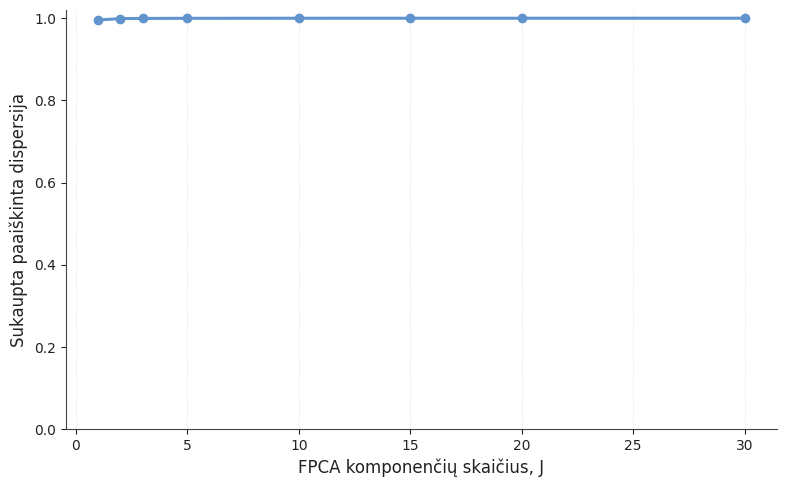

In [12]:
fpca_info_df = pd.DataFrame(fpca_info_rows)

fig, ax = plt.subplots(figsize=(8.0, 5.0))

ax.plot(
    fpca_info_df["J"],
    fpca_info_df["cum_explained_variance"],
    marker="o",
    linewidth=2.2,
    color=COLOR_PRIMARY,
)

ax.set_xlabel("FPCA komponenčių skaičius, J")
ax.set_ylabel("Sukaupta paaiškinta dispersija")
ax.set_ylim(0, 1.02)

apply_clean_axes(ax, add_grid=True)
show_and_save(fig, OUT_DIR / "fig_fpca_cumulative_variance.svg")



 ## 12. Top-model comparison plot



 The best-performing models are compared using F1, PR-AUC, sensitivity, and

 specificity.

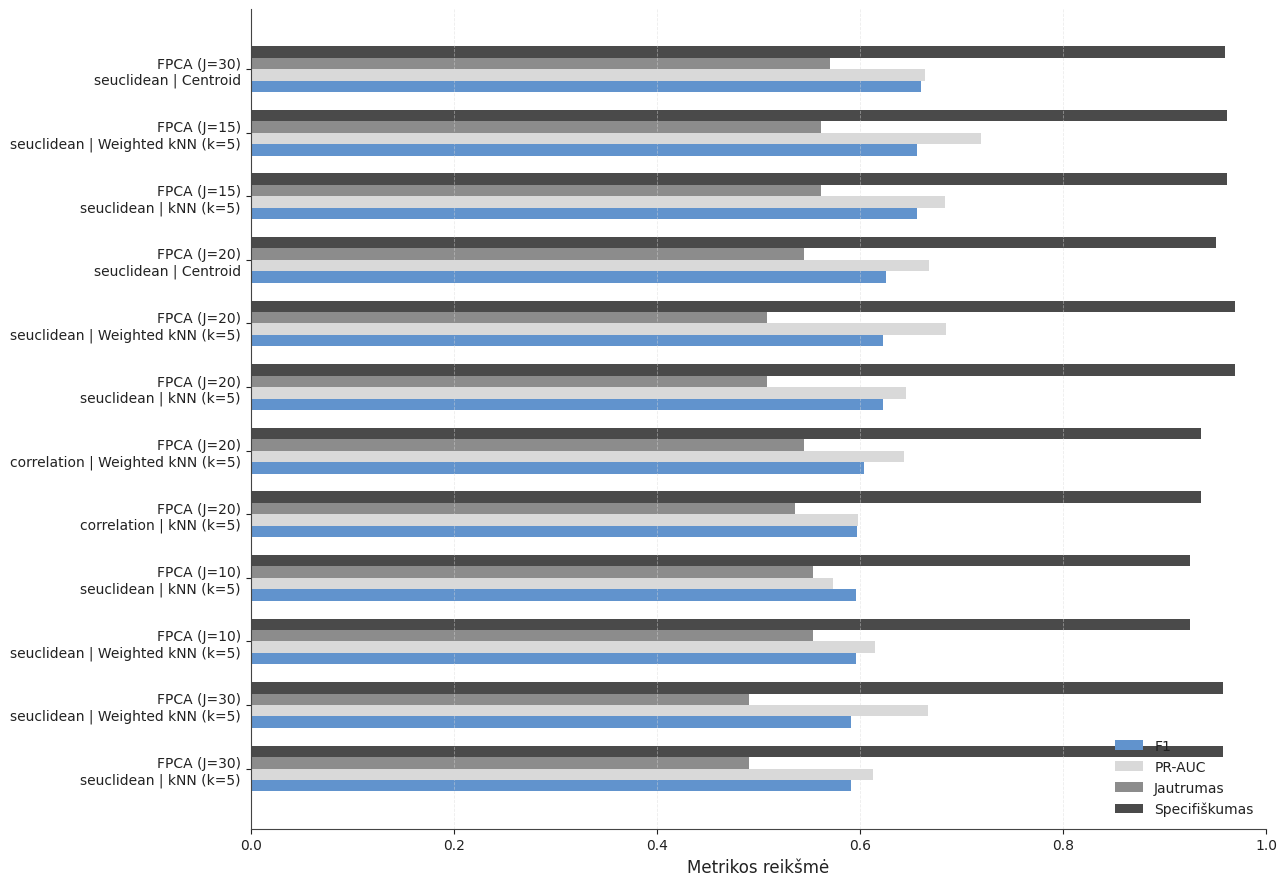

In [13]:
plot_df = results_df.copy()
plot_df["label"] = (
    plot_df["feature_space"]
    + "\n"
    + plot_df["distance"]
    + " | "
    + plot_df["model"]
)

plot_df = plot_df.sort_values("f1", ascending=False).head(TOP_N_PLOT).copy()
plot_df = plot_df.sort_values("f1", ascending=True)

y_pos = np.arange(len(plot_df))
bar_height = 0.18

fig, ax = plt.subplots(figsize=(13, 9))

ax.barh(
    y_pos - 1.5 * bar_height,
    plot_df["f1"],
    height=bar_height,
    label="F1",
    color=COLOR_PRIMARY,
)
ax.barh(
    y_pos - 0.5 * bar_height,
    plot_df["pr_auc"],
    height=bar_height,
    label="PR-AUC",
    color=COLOR_LIGHT,
)
ax.barh(
    y_pos + 0.5 * bar_height,
    plot_df["sensitivity"],
    height=bar_height,
    label="Jautrumas",
    color=COLOR_SECONDARY,
)
ax.barh(
    y_pos + 1.5 * bar_height,
    plot_df["specificity"],
    height=bar_height,
    label="Specifiškumas",
    color=COLOR_DARK,
)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Metrikos reikšmė")
ax.set_xlim(0, 1.0)
ax.legend(frameon=False, loc="lower right")

apply_clean_axes(ax, add_grid=True)
show_and_save(fig, OUT_DIR / "fig_top_fpca_models.svg")



 ## 13. Distance comparison within FPCA space



 These pivot tables make it easier to compare how each distance metric behaves

 across FPCA settings and classifier types.

In [14]:
distance_comparison_f1_df = results_df.pivot_table(
    index=["feature_space", "distance"],
    columns="model",
    values="f1",
)

distance_comparison_pr_auc_df = results_df.pivot_table(
    index=["feature_space", "distance"],
    columns="model",
    values="pr_auc",
)

print("\n=== F1 BY FPCA SETTING AND DISTANCE ===")
display(distance_comparison_f1_df.round(3))

print("\n=== PR-AUC BY FPCA SETTING AND DISTANCE ===")
display(distance_comparison_pr_auc_df.round(3))




=== F1 BY FPCA SETTING AND DISTANCE ===


model                      Centroid  Medoid  Weighted kNN (k=5)  kNN (k=5)
feature_space distance                                                    
FPCA (J=1)    correlation     0.000   0.000               0.000      0.000
              cosine          0.321   0.000               0.000      0.000
              euclidean       0.324   0.312               0.202      0.092
              mahalanobis     0.324   0.312               0.212      0.092
              manhattan       0.324   0.312               0.202      0.092
              seuclidean      0.324   0.312               0.212      0.092
FPCA (J=10)   correlation     0.321   0.378               0.559      0.560
              cosine          0.321   0.395               0.544      0.562
              euclidean       0.324   0.312               0.452      0.443
              mahalanobis     0.324   0.312               0.486      0.469
              manhattan       0.325   0.319               0.451      0.451
              seuclidean      0.500   0.541               0.596      0.596
FPCA (J=15)   correlation     0.321   0.385               0.567      0.563
              cosine          0.321   0.383               0.548      0.561
              euclidean       0.324   0.312               0.429      0.423
              mahalanobis     0.324   0.316               0.431      0.425
              manhattan       0.325   0.318               0.458      0.458
              seuclidean      0.562   0.530               0.656      0.656
FPCA (J=2)    correlation     0.320   0.000               0.015      0.015
              cosine          0.321   0.343               0.226      0.202
              euclidean       0.324   0.312               0.227      0.184
              mahalanobis     0.324   0.312               0.232      0.206
              manhattan       0.325   0.312               0.210      0.176
              seuclidean      0.374   0.361               0.193      0.230
FPCA (J=20)   correlation     0.321   0.383               0.604      0.597
              cosine          0.321   0.385               0.579      0.574
              euclidean       0.324   0.312               0.411      0.405
              mahalanobis     0.324   0.316               0.446      0.437
              manhattan       0.325   0.318               0.517      0.517
              seuclidean      0.626   0.480               0.623      0.623
FPCA (J=3)    correlation     0.321   0.306               0.200      0.182
              cosine          0.321   0.354               0.303      0.258
              euclidean       0.324   0.312               0.227      0.211
              mahalanobis     0.324   0.312               0.220      0.224
              manhattan       0.325   0.317               0.224      0.214
              seuclidean      0.388   0.382               0.343      0.320
FPCA (J=30)   correlation     0.321   0.387               0.577      0.577
              cosine          0.321   0.385               0.557      0.557
              euclidean       0.324   0.312               0.402      0.395
              mahalanobis     0.324   0.316               0.431      0.422
              manhattan       0.325   0.319               0.523      0.523
              seuclidean      0.660   0.477               0.591      0.591
FPCA (J=5)    correlation     0.321   0.315               0.362      0.421
              cosine          0.321   0.400               0.469      0.475
              euclidean       0.324   0.312               0.407      0.398
              mahalanobis     0.324   0.312               0.447      0.420
              manhattan       0.325   0.321               0.422      0.404
              seuclidean      0.444   0.479               0.569      0.562


=== PR-AUC BY FPCA SETTING AND DISTANCE ===


model                      Centroid  Medoid  Weighted kNN (k=5)  kNN (k=5)
feature_space distance                                                    
FPCA (J=1)    correlation     0.199   0.199               0.199      0.199
              cosine          0.199   0.198               0.199      0.199
              euclidean       0.216   0.220               0.223      0.214
              mahalanobis     0.216   0.220               0.229      0.214
              manhattan       0.216   0.220               0.223      0.214
              seuclidean      0.216   0.220               0.229      0.214
FPCA (J=10)   correlation     0.387   0.373               0.546      0.517
              cosine          0.385   0.382               0.557      0.536
              euclidean       0.233   0.245               0.487      0.444
              mahalanobis     0.239   0.219               0.539      0.501
              manhattan       0.262   0.240               0.519      0.481
              seuclidean      0.541   0.535               0.615      0.574
FPCA (J=15)   correlation     0.386   0.373               0.624      0.585
              cosine          0.389   0.366               0.596      0.558
              euclidean       0.233   0.244               0.495      0.450
              mahalanobis     0.240   0.225               0.532      0.491
              manhattan       0.270   0.250               0.550      0.502
              seuclidean      0.598   0.587               0.719      0.684
FPCA (J=2)    correlation     0.200   0.199               0.200      0.200
              cosine          0.284   0.273               0.263      0.257
              euclidean       0.221   0.212               0.254      0.253
              mahalanobis     0.225   0.212               0.258      0.264
              manhattan       0.228   0.216               0.259      0.257
              seuclidean      0.305   0.256               0.245      0.251
FPCA (J=20)   correlation     0.388   0.366               0.643      0.598
              cosine          0.390   0.367               0.643      0.600
              euclidean       0.234   0.245               0.506      0.460
              mahalanobis     0.240   0.225               0.536      0.487
              manhattan       0.277   0.250               0.608      0.556
              seuclidean      0.668   0.430               0.685      0.645
FPCA (J=3)    correlation     0.267   0.238               0.244      0.245
              cosine          0.292   0.280               0.284      0.281
              euclidean       0.226   0.222               0.286      0.280
              mahalanobis     0.226   0.221               0.285      0.279
              manhattan       0.234   0.230               0.287      0.274
              seuclidean      0.325   0.280               0.337      0.317
FPCA (J=30)   correlation     0.389   0.369               0.632      0.590
              cosine          0.391   0.368               0.613      0.572
              euclidean       0.234   0.258               0.498      0.449
              mahalanobis     0.240   0.225               0.526      0.476
              manhattan       0.281   0.242               0.607      0.565
              seuclidean      0.664   0.428               0.667      0.613
FPCA (J=5)    correlation     0.316   0.275               0.327      0.359
              cosine          0.374   0.388               0.439      0.428
              euclidean       0.232   0.215               0.447      0.410
              mahalanobis     0.236   0.219               0.494      0.460
              manhattan       0.254   0.236               0.459      0.427
              seuclidean      0.463   0.390               0.547      0.510

 ## 14. Eigenspectra from the largest FPCA model



 This figure shows the first few FPCA loading curves from the model with the

 largest tested number of components.

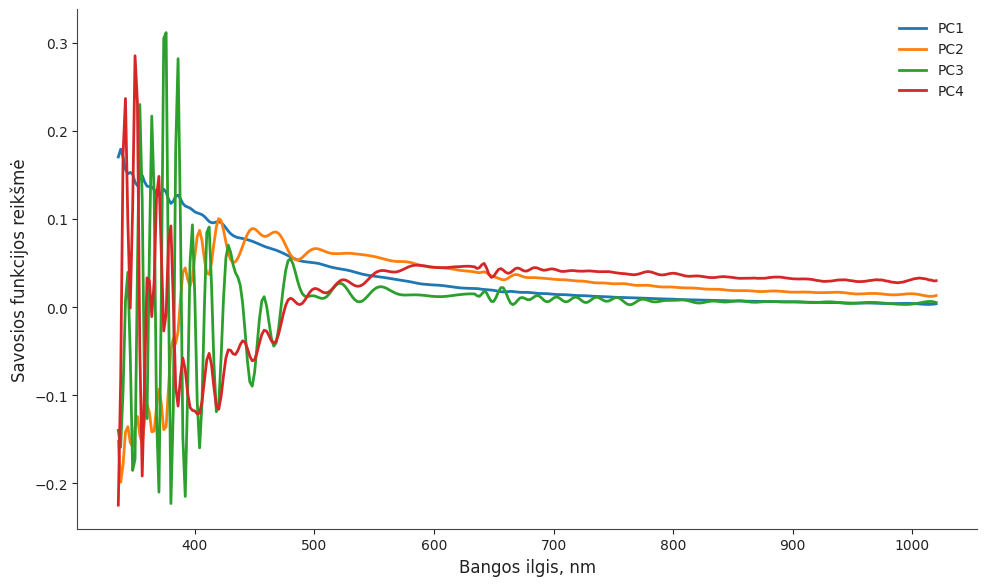

In [15]:
J_plot = max(J_VALUES)

(
    _,
    _,
    explained_ratio_plot,
    variances_plot,
    mu_plot,
    right_singular_vectors_plot,
) = fpca_fit_transform(X_tr, X_te, J_plot)

n_plot = min(4, right_singular_vectors_plot.shape[0])

fig, ax = plt.subplots(figsize=(10, 6))

for component_idx in range(n_plot):
    ax.plot(
        wavelengths,
        right_singular_vectors_plot[component_idx],
        linewidth=2.0,
        label=f"PC{component_idx + 1}",
    )

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Savosios funkcijos reikšmė")
ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_fpca_eigenspectra.svg")



 ## 15. Mean normalized spectra by class



 This figure shows the L2-normalised mean spectrum for each class.

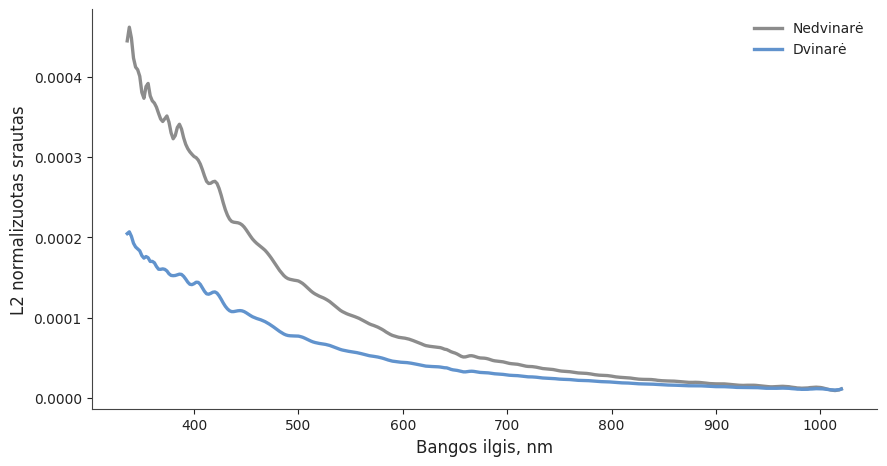

In [16]:
mu_0 = X[y == 0].mean(axis=0)
mu_1 = X[y == 1].mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.plot(
    wavelengths,
    mu_0,
    linewidth=2.4,
    color=COLOR_SECONDARY,
    label="Nedvinarė",
)
ax.plot(
    wavelengths,
    mu_1,
    linewidth=2.4,
    color=COLOR_PRIMARY,
    label="Dvinarė",
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_class_mean_spectra_fpca_input.svg")



 ## 16. Separation strength across wavelength



 This figure shows the squared difference between the binary and non-binary

 mean spectra at each wavelength. Larger values indicate stronger

 wavelength-wise class separation.

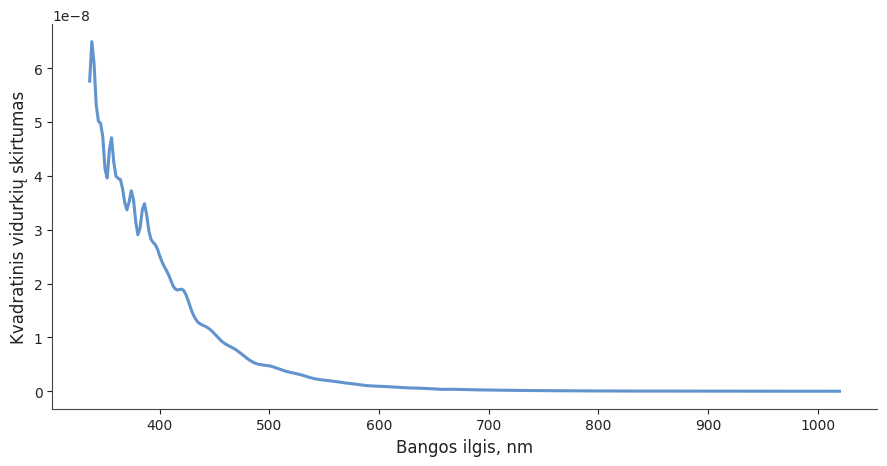

In [17]:
mean_diff_sq = (mu_1 - mu_0) ** 2

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.plot(
    wavelengths,
    mean_diff_sq,
    linewidth=2.2,
    color=COLOR_PRIMARY,
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Kvadratinis vidurkių skirtumas")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_class_mean_difference_fpca_input.svg")



 ## 17. Save main table outputs



 Figure outputs are saved immediately after each plotting block above. This

 section saves only CSV tables.

In [18]:
results_df.to_csv(
    OUT_DIR / "fpca_distance_results.csv",
    index=False,
)

best_by_j_df.to_csv(
    OUT_DIR / "fpca_distance_best_by_j.csv",
    index=False,
)

fpca_info_df.to_csv(
    OUT_DIR / "fpca_explained_variance.csv",
    index=False,
)

print("Saved main CSV outputs to:", OUT_DIR)



Saved main CSV outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\02_initial_model_testing


 ## 18. Final quick view



 The final display shows the best overall model and the best model within each

 FPCA setting.

In [19]:
print("Best overall model:")
display(best_df.head(1))

print("Best model within each FPCA dimension:")
display(best_by_j_df)

Best overall model:


,representation,feature_space,distance,model,accuracy,precision,recall,sensitivity,specificity,f1,pr_auc
0,Sampled spectra,FPCA (J=30),seuclidean,Centroid,0.883,0.78,0.571,0.571,0.96,0.66,0.664


Best model within each FPCA dimension:


,feature_space,representation,distance,model,accuracy,precision,recall,sensitivity,specificity,f1,pr_auc
0,FPCA (J=1),Sampled spectra,euclidean,Centroid,0.332,0.203,0.804,0.804,0.215,0.324,0.216
1,FPCA (J=10),Sampled spectra,seuclidean,Weighted kNN (k=5),0.851,0.646,0.554,0.554,0.925,0.596,0.615
2,FPCA (J=15),Sampled spectra,seuclidean,Weighted kNN (k=5),0.883,0.788,0.562,0.562,0.962,0.656,0.719
3,FPCA (J=2),Sampled spectra,seuclidean,Centroid,0.423,0.238,0.866,0.866,0.313,0.374,0.305
4,FPCA (J=20),Sampled spectra,seuclidean,Centroid,0.870,0.735,0.545,0.545,0.951,0.626,0.668
5,FPCA (J=3),Sampled spectra,seuclidean,Centroid,0.485,0.254,0.821,0.821,0.401,0.388,0.325
6,FPCA (J=30),Sampled spectra,seuclidean,Centroid,0.883,0.780,0.571,0.571,0.960,0.660,0.664
7,FPCA (J=5),Sampled spectra,seuclidean,Weighted kNN (k=5),0.838,0.606,0.536,0.536,0.914,0.569,0.547
